Source: This example comes from the torch adaptation of Charles Ollion [/github/charlesollion].

In [133]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt

Data Acquisition

In [134]:
!python3 -m wget https://raw.githubusercontent.com/LuisM78/Appliances-energy-prediction-data/master/energydata_complete.csv

C:\Users\anton\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe: No module named wget


Data loading and preprocessing. Data is similar to project work, and has

In [135]:
df = pd.read_csv("Datasets/DailyDelhiClimateTrain.csv", index_col='date', parse_dates=['date'])
print(df.head())

             meantemp   humidity  wind_speed  meanpressure
date                                                      
2013-01-01  10.000000  84.500000    0.000000   1015.666667
2013-01-02   7.400000  92.000000    2.980000   1017.800000
2013-01-03   7.166667  87.000000    4.633333   1018.666667
2013-01-04   8.666667  71.333333    1.233333   1017.166667
2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [136]:
features = list(df.columns)
data = df.values

Function for splitting the dataset into sequences of observations of length history size.

In [137]:
def sequencing(dataset, start_index=0, end_index=None, history_size=13, step=1):
    data = []
    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset)
    for i in range(start_index, end_index):
        indices = range(i - history_size, i, step)
        data.append(dataset[indices])
    return np.array(data)


Function for splitting the dataset into training and validation, and data normalization.

In [138]:
def partition(data, pTrain=0.7, pVal = 0.5, save_path=None):
    # I don't like this normalization before training thingie
    data_mean = data.mean(axis=0)
    data_std = data.std(axis=0)
    data = (data - data_mean)/data_std
    stats = (data_mean, data_std)

    sequencedData = sequencing(data, start_index=0, end_index=None, history_size=13, step=1)

    dataTrain, dataVal = train_test_split(sequencedData, train_size=pTrain, shuffle=True, random_state=123)
    dataVal, dataTest = train_test_split(dataVal, train_size=pVal, shuffle=True, random_state=123)

    return dataTrain, dataVal, dataTest, stats

Create input-output pairs.

In [139]:
def split(chunk):
    inputs = torch.tensor(chunk[:, :-1, :], dtype=torch.float32, device=device)
    targets = torch.tensor(chunk[:, 1:, :], dtype=torch.float32, device=device)
    return inputs, targets

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Loaders

In [140]:
def createLoaders(dataTrain, dataVal, dataTest, batchSize=32, responseVariables=None):
    XTrain, YTrain = split(dataTrain)
    XVal, YVal = split(dataVal)
    XTest, YTest = split(dataTest)

    # default: use all response features present in Y tensors
    if responseVariables is None:
        responseVariables = list(range(YTrain.size(2)))
    else:
        responseVariables = list(responseVariables)
        if len(responseVariables) == 0:
            responseVariables = list(range(YTrain.size(2)))
        # validate indices
        if min(responseVariables) < 0 or max(responseVariables) >= YTrain.size(2):
            raise IndexError(f"responseVariables indices out of range for Y with shape {YTrain.shape}")

    YTrain = YTrain[:, :, responseVariables]
    YVal = YVal[:, :, responseVariables]
    YTest = YTest[:, :, responseVariables]

    trainDS = torch.utils.data.TensorDataset(XTrain, YTrain)
    valDS = torch.utils.data.TensorDataset(XVal, YVal)
    testDS = torch.utils.data.TensorDataset(XTest, YTest)

    trainLoader = torch.utils.data.DataLoader(trainDS, batch_size=batchSize)
    valLoader = torch.utils.data.DataLoader(valDS, batch_size=batchSize)
    testLoader = torch.utils.data.DataLoader(testDS, batch_size=batchSize)

    return trainLoader, valLoader, testLoader

hum_idx = features.index('humidity')

trainData, valData, testData, stats = partition(data)
trainDataset, valDataset, testDataset = createLoaders(trainData, valData, testData, responseVariables=[hum_idx])



Transformer NN implementation

In [141]:
import torch.nn as nn
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, D, H):
        super(MultiHeadAttention, self).__init__()
        self.H = H # number of heads
        self.D = D # dimension
        
        self.wq = nn.Linear(D, D*H)
        self.wk = nn.Linear(D, D*H)
        self.wv = nn.Linear(D, D*H)

        self.dense = nn.Linear(D*H, D)

    def concat_heads(self, x):
        '''(B, H, S, D) => (B, S, D*H)'''
        B, H, S, D = x.shape
        x = x.permute((0, 2, 1, 3)).contiguous()  # (B, S, H, D)
        x = x.reshape((B, S, H*D))   # (B, S, D*H)
        return x

    def split_heads(self, x):
        '''(B, S, D*H) => (B, H, S, D)'''
        B, S, D_H = x.shape
        x = x.reshape(B, S, self.H, self.D)    # (B, S, H, D)
        x = x.permute((0, 2, 1, 3))  # (B, H, S, D)
        return x

    def forward(self, x, mask):

        q = self.wq(x)  # (B, S, D*H)
        k = self.wk(x)  # (B, S, D*H)
        v = self.wv(x)  # (B, S, D*H)

        q = self.split_heads(q)  # (B, H, S, D)
        k = self.split_heads(k)  # (B, H, S, D)
        v = self.split_heads(v)  # (B, H, S, D)

        attention_scores = torch.matmul(q, k.transpose(-1, -2)) #(B,H,S,S)
        attention_scores = attention_scores / math.sqrt(self.D)

        # add the mask to the scaled tensor.
        if mask is not None:
            attention_scores += (mask * -1e9)
        
        attention_weights = nn.Softmax(dim=-1)(attention_scores)
        scaled_attention = torch.matmul(attention_weights, v)  # (B, H, S, D)
        concat_attention = self.concat_heads(scaled_attention) # (B, S, D*H)
        output = self.dense(concat_attention)  # (B, S, D)

        return output, attention_weights

In [142]:
B, S, H, D = 9, 11, 5, 8
mha = MultiHeadAttention(D, H)
out, att = mha.forward(torch.zeros(B, S, D), mask=None)
out.shape, att.shape

(torch.Size([9, 11, 8]), torch.Size([9, 5, 11, 11]))

In [143]:
# Positional encodings
def get_angles(pos, i, D):
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(D))
    return pos * angle_rates


def positional_encoding(D, position=20, dim=3, device=device):
    angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                            np.arange(D)[np.newaxis, :],
                            D)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    if dim == 3:
        pos_encoding = angle_rads[np.newaxis, ...]
    elif dim == 4:
        pos_encoding = angle_rads[np.newaxis,np.newaxis,  ...]
    return torch.tensor(pos_encoding, dtype=torch.float32, device=device)

# function that implement the look_ahead mask for masking future time steps. 
def create_look_ahead_mask(size, device=device):
    mask = torch.ones((size, size), device=device)
    mask = torch.triu(mask, diagonal=1)
    return mask  # (size, size)

create_look_ahead_mask(6)

class TransformerLayer(nn.Module):
    def __init__(self, D, H, hidden_mlp_dim, dropout_rate):
        super(TransformerLayer, self).__init__()
        self.dropout_rate = dropout_rate
        self.mlp_hidden = nn.Linear(D, hidden_mlp_dim)
        self.mlp_out = nn.Linear(hidden_mlp_dim, D)
        self.layernorm1 = nn.LayerNorm(D, eps=1e-9)
        self.layernorm2 = nn.LayerNorm(D, eps=1e-9)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.mha = MultiHeadAttention(D, H)


    def forward(self, x, look_ahead_mask):
        
        attn, attn_weights = self.mha(x, look_ahead_mask)  # (B, S, D)
        attn = self.dropout1(attn) # (B,S,D)
        attn = self.layernorm1(attn + x) # (B,S,D)

        mlp_act = torch.relu(self.mlp_hidden(attn))
        mlp_act = self.mlp_out(mlp_act)
        mlp_act = self.dropout2(mlp_act)
        
        output = self.layernorm2(mlp_act + attn)  # (B, S, D)

        return output, attn_weights

In [144]:
dl = TransformerLayer(16, 3, 32, 0.1)
out, attn = dl(x=torch.zeros(5, 7, 16), look_ahead_mask=None)
out.shape, attn.shape

(torch.Size([5, 7, 16]), torch.Size([5, 3, 7, 7]))

In [145]:
class Transformer(nn.Module):
    '''Transformer Decoder Implementating several Decoder Layers.
    '''
    def __init__(self, num_layers, D, H, hidden_mlp_dim, inp_features, out_features, dropout_rate):
        super(Transformer, self).__init__()
        self.sqrt_D = torch.tensor(math.sqrt(D), dtype=torch.float32, device=device)
        self.num_layers = num_layers
        self.input_projection = nn.Linear(inp_features, D) # multivariate input
        self.output_projection = nn.Linear(D, out_features) # multivariate output
        self.pos_encoding = positional_encoding(D)
        self.dec_layers = nn.ModuleList([TransformerLayer(D, H, hidden_mlp_dim, 
                                        dropout_rate=dropout_rate
                                       ) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x, mask):
        B, S, D = x.shape
        attention_weights = {}
        x = self.input_projection(x)
        x *= self.sqrt_D
        
        x += self.pos_encoding[:, :S, :]

        x = self.dropout(x)

        for i in range(self.num_layers):
            x, block = self.dec_layers[i](x=x,
                                          look_ahead_mask=mask)
            attention_weights['decoder_layer{}'.format(i + 1)] = block
        
        x = self.output_projection(x)
        
        return x, attention_weights # (B,S,S)

In [146]:
# Test Forward pass on the Transformer: 
transformer = Transformer(num_layers=1, D=32, H=1, hidden_mlp_dim=32,
                                       inp_features=28, out_features=20, dropout_rate=0.1)
transformer.to(device)
(inputs, targets) = next(iter(trainDataset))
inp_dim = inputs.shape[2]
out_dim = targets.shape[2]

transformer = Transformer(num_layers=1, D=32, H=4, hidden_mlp_dim=32,
                          inp_features=inp_dim, out_features=out_dim, dropout_rate=0.1).to(device)
optimizer = torch.optim.RMSprop(transformer.parameters(), lr=0.00005)

S = inputs.shape[1]
mask = create_look_ahead_mask(S)
out, attn = transformer(x=inputs, mask=mask)
out.shape, attn["decoder_layer1"].shape

(torch.Size([32, 12, 1]), torch.Size([32, 4, 12, 12]))

Training the Transformer

In [147]:
param_sizes = [p.numel() for p in transformer.parameters()]
print(f"number of weight/biases matrices: {len(param_sizes)} "
      f"for a total of {np.sum(param_sizes)} parameters ")

number of weight/biases matrices: 20 for a total of 19233 parameters 


In [148]:
(inputs_check, targets_check) = next(iter(trainDataset))
inp_dim = inputs_check.shape[2]
out_dim = targets_check.shape[2]

transformer = Transformer(num_layers=1, D=32, H=4, hidden_mlp_dim=32,
                          inp_features=inp_dim, out_features=out_dim, dropout_rate=0.1).to(device)
optimizer = torch.optim.RMSprop(transformer.parameters(), lr=0.00005)

In [149]:
!pip3 install tqdm
from tqdm import tqdm

n_epochs = 20
niter = len(trainDataset)
losses, val_losses = [], []

for e in tqdm(range(n_epochs)):

    transformer.train()
    sum_train_loss = 0.0
    for x, y in trainDataset:
        S = x.shape[1]
        mask = create_look_ahead_mask(S)
        out, _ = transformer(x, mask)
        loss = torch.nn.MSELoss()(out, y)
        sum_train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses.append(sum_train_loss / niter)

    transformer.eval()
    sum_val_loss = 0.0
    for i, (x, y) in enumerate(valDataset):
        S = x.shape[1]
        mask = create_look_ahead_mask(S)
        out, _ = transformer(x, mask)
        loss = torch.nn.MSELoss()(out, y)
        sum_val_loss += loss.item()
    val_losses.append(sum_val_loss / (i + 1))

100%|██████████| 20/20 [00:07<00:00,  2.84it/s]


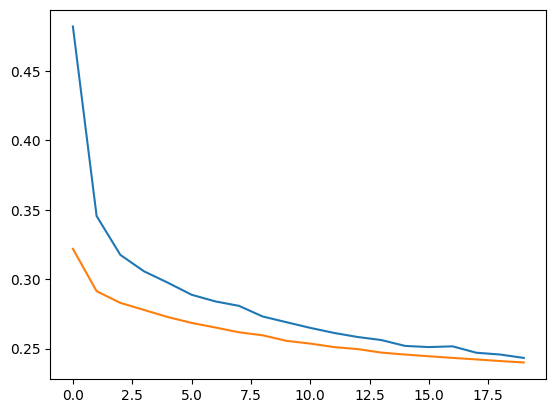

In [150]:
plt.plot(losses)
plt.plot(val_losses)

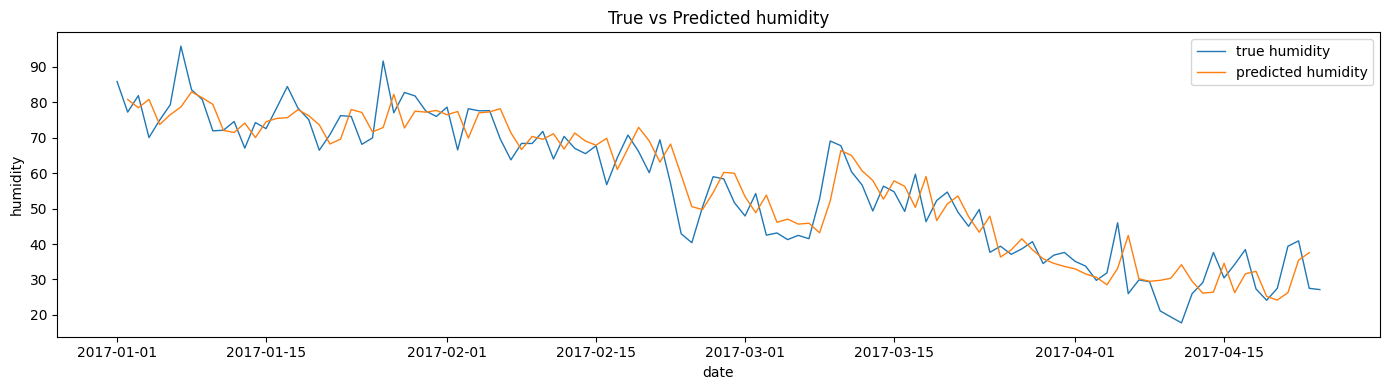

In [151]:
df_test = pd.read_csv("Datasets/DailyDelhiClimateTest.csv", index_col='date', parse_dates=['date'])
df_test = df_test[features]
N = len(df_test)

data_mean, data_std = stats
data_test_norm = (df_test.values - data_mean) / data_std

history_size = 13
seq_test = sequencing(data_test_norm, start_index=0, end_index=None, history_size=history_size, step=1)
X_test, Y_test = split(seq_test)
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test, Y_test), batch_size=32)

transformer.eval()
y_preds_list = []
with torch.no_grad():
    for xb, _ in test_loader:
        S = xb.shape[1]
        mask = create_look_ahead_mask(S).to(device)
        yp, _ = transformer(xb.to(device), mask)
        y_preds_list.append(yp.cpu().numpy())

y_preds = np.concatenate(y_preds_list, axis=0)

idx = hum_idx
y_preds_den = y_preds * data_std[None, None, idx] + data_mean[None, None, idx]

n_windows, S, _ = y_preds_den.shape

pred_sum = np.zeros(N, dtype=float)
pred_count = np.zeros(N, dtype=float)

for k in range(n_windows):
    for t in range(S):
        date_idx = k + 1 + t
        if 0 <= date_idx < N:
            pred_sum[date_idx] += float(y_preds_den[k, t, 0])
            pred_count[date_idx] += 1.0

pred_avg = np.full(N, np.nan)
mask_nonzero = pred_count > 0
pred_avg[mask_nonzero] = pred_sum[mask_nonzero] / pred_count[mask_nonzero]

true_humidity = df_test.iloc[:, hum_idx].values

out_df = pd.DataFrame({
    "date": df_test.index,
    "true_humidity": true_humidity,
    "pred_humidity": pred_avg
})

plt.figure(figsize=(14,4))
plt.plot(df_test.index, true_humidity, label="true humidity", linewidth=1)
plt.plot(df_test.index, pred_avg, label="predicted humidity", linewidth=1)
plt.legend()
plt.title("True vs Predicted humidity")
plt.xlabel("date")
plt.ylabel("humidity")
plt.tight_layout()
plt.show()